In [18]:
from myutils import cache, clean_all_cache

from src import *
from glob import glob

from src.fisherinfo import FisherInformation, ApproxFisherInformation, FrequencyCFI

from matplotlib.ticker import AutoMinorLocator

In [24]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

In [19]:
clean_all_cache()

done


In [20]:
@cache
def read_est(A):
    files = [
        f'__estimates__/0noise/spade_{A}px/spade_{A}px_' + 'f{}_d0.npz',
        f'__estimates__/0noise/di_{A}px/di_{A}px_' + 'f{}_d0.npz'
    ]

    di_means, di_vars, spade_means, spade_vars = [], [], [], []

    for file in files:
        for f in np.linspace(0.1, 0.4, 61):
            c = LoadEstimates(file.format(np.round(f, 5))) 
            if c.metadata.measurement == 'DI':
                di_means.append(c.estimates_a.mean())
                di_vars.append(c.estimates_a.var(ddof=1) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))
            elif c.metadata.measurement == 'SPADE':
                spade_means.append(c.estimates_a.mean())
                spade_vars.append(c.estimates_a.var(ddof=1) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))

    return np.array(di_means), np.array(di_vars), np.array(spade_means), np.array(spade_vars)

cache hit: reading result from cache file
cache hit: reading result from cache file


/var/folders/69/gvvxj34j7cx90fmrj81xbl7c0000gn/T/ipykernel_17850/420650380.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


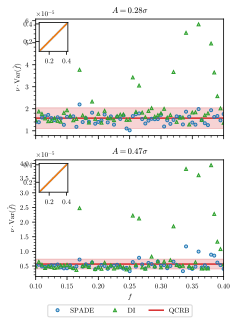

In [80]:
fig, ax = plt.subplots(2, 1, figsize=(width, width * 2.1*0.618), sharex=True)

for ax_ in ax:
    ax_.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax_.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax_.ticklabel_format(style='sci', axis='y')

    ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax_.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax_.set_xlim(0.1, 0.4)
    ax_.set_box_aspect(0.618)


for i, A in enumerate([3, 5]):
    x_axis = np.linspace(0.1, 0.4, 3)
    crb = np.array(list(1 / ApproxFisherInformation([A * DMD.PIXEL_SIZE / 2])) * 3)

    crb_line, = ax[i].plot(x_axis, crb, red)

    ax[i].set_ylabel(r'$\nu\cdot{\rm Var}(\hat{f})$')
    ax[i].set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')

    ax[i].fill_between(x_axis, 0.7 * np.array(crb), 1.3 * np.array(crb), color=red, alpha=0.2)


for i, A in enumerate([3, 5]):
    di_means, di_vars, spade_means, spade_vars = read_est(A)
    x_axis = np.linspace(0.1, 0.4, 61)

    line1, = ax[i].plot(x_axis, spade_vars, 
                    marker='o', linestyle='', markersize=3,
                    markeredgecolor=c1, markerfacecolor=(c1, 0.3))

    line2, = ax[i].plot(x_axis, di_vars,
                    marker='^', linestyle='', markersize=3,
                    markeredgecolor=c2, markerfacecolor=(c2, 0.3))
    
    ax_inset = inset_axes(ax[i], width=0.4, height=0.4, loc='upper left')
    ax_inset.plot(x_axis, spade_means)
    ax_inset.plot(x_axis, di_means)


ax[1].set_xlabel(r'$f$')

fig.legend([line1, line2, crb_line], ['SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
# plt.savefig('ideal.pdf')
plt.show()